# Out of distribution testing and model comparison
This notebook is dedicated to evaluating and comparing the generalization capabilities of pre-trained robotic models on Out-of-Distribution (OOD) datasets.
*   Assesses model performance on data distributions not seen during training, specifically targeting robust torque estimation across varying trajectories.

*   Facilitates a direct comparison between a Shallow Network and a Deep Network to analyze how architectural depth affects generalization.

*   Implements the PklDataset class to load OOD data while applying the mean and standard deviation statistics from the original training set to ensure  consistency.

*   Loads model weights and optimizer states from checkpoints stored on Google Drive, allowing for immediate testing of finalized training runs.
*   Calculates Mean Squared Error (MSE) and Normalized MSE (nMSE) both globally and on a per-joint basis to identify specific axis-related performance drops

*   Includes dedicated plotting functions to visualize predicted vs. real torques over time, alongside error residuals, providing qualitative insights into model drift.


*   Generates summary bar plots to visualize the performance gap between shallow and deep architectures across all robot joints.



In [1]:
import numpy as np
import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt
import glob
import os
import random
import torch
import re # regular expressions


import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [2]:
from google.colab import drive

In [3]:
drive.flush_and_unmount()

In [4]:
drive.mount('/content/drive')

Mounted at /content/drive


## NETWORK DEFINITION

In [5]:
class Net(nn.Module):

    def __init__(self, Ni, Nh1, Nh2, No):
        """
        Ni - Input size
        Nh1 - Neurons in the 1st hidden layer
        Nh2 - Neurons in the 2nd hidden layer
        No - Output size
        """
        super().__init__()

        self.fc1 = nn.Linear(Ni, Nh1)
        self.fc2 = nn.Linear(Nh1, Nh2)
        self.out = nn.Linear(Nh2, No)
        self.act = nn.ReLU()

    def forward(self, x, additional_out=False):

        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        x = self.out(x)
        return x

In [6]:
class DeepNet(nn.Module):

    def __init__(self, Ni, Nh1, Nh2, Nh3, Nh4, Nh5, No):
        """
        Ni - Input size
        Nh1 - Neurons in the 1st hidden layer
        Nh2 - Neurons in the 2nd hidden layer
        No - Output size
        """
        super().__init__()

        self.fc1 = nn.Linear(Ni, Nh1)
        self.fc2 = nn.Linear(Nh1, Nh2)
        self.fc3 = nn.Linear(Nh2, Nh3)
        self.fc4 = nn.Linear(Nh3, Nh4)
        self.fc5 = nn.Linear(Nh4, Nh5)
        self.out = nn.Linear(Nh5, No)

        self.act = nn.ReLU()

    def forward(self, x, additional_out=False):
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        x = self.act(self.fc3(x))
        x = self.act(self.fc4(x))
        x = self.act(self.fc5(x))
        x = self.out(x)
        return x


## Definizione classe PklDataset

In [7]:
# class PklDataset(Dataset):
#     """
#     Dataset class to load and process robotic state data from pickle files.
#     Expected data includes joint positions (q), velocities (dq),
#     accelerations (ddq), and noiseless torques (tau).
#     """
#     def __init__(self, pkl_folder, random_choice=False, transform=None, normalize_y=False, mean_y=None, std_y=None):
#         self.transform = transform
#         self.normalize_y = normalize_y

#         match = re.search(r"(\d+)dof", pkl_folder)
#         if not match:
#             raise ValueError(f"Impossibile estrarre i DOF dal nome file: {pkl_folder}")
#         self.n_dof = int(match.group(1))

#         columns = []
#         for j in range(1, self.n_dof + 1):
#             columns += [f"q_{j}", f"dq_{j}", f"ddq_{j}"]
#         for j in range(1, self.n_dof + 1):
#             columns += [f"tau_noiseless_{j}"]

#         # Read all the files one by one and put them inside a list
#         pkl_files = glob.glob(os.path.join(pkl_folder,'*.pkl'))

#         self.data = []
#         all_y = []

#         if not random_choice:
#           for file_path in pkl_files:
#             df = pd.read_pickle(file_path)
#             np_array = df[columns].to_numpy()
#             X = np_array[:, :(3*self.n_dof)]   # 6 features
#             y = np_array[:, (3*self.n_dof):]   # 2 labels
#             for i in range(np_array.shape[0]):
#               self.data.append((X[i], y[i]))  # tuple (input, label)
#             all_y.append(y)

#         else:
#           random_file = random.choice(pkl_files)
#           df = pd.read_pickle(random_file)
#           np_array = df[columns].to_numpy()
#           X = np_array[:, :(3*self.n_dof)]   # 6 features
#           y = np_array[:, (3*self.n_dof):]   # 2 labels
#           for i in range(np_array.shape[0]):
#             self.data.append((X[i], y[i]))  # tuple (input, label)
#           all_y.append(y)

#         if normalize_y:
#           if mean_y is not None and std_y is not None:
#             self.mean_y = mean_y
#             self.std_y = std_y
#           else:
#             all_y = np.vstack(all_y)
#             self.mean_y = np.mean(all_y, axis=0)
#             self.std_y = np.std(all_y, axis=0)
#             self.std_y[self.std_y == 0] = 1
#           self.mean_y = np.zeros(self.n_dof)
#           self.std_y = np.ones(self.n_dof)

#     def __len__(self):
#         # The length of the dataset is simply the length of the self.data list
#         return len(self.data)

#     def __getitem__(self, idx):
#         # Our sample is the element idx of the list self.data
#         sample = self.data[idx]

#         if self.normalize_y:
#             sample = (sample[0], (sample[1] - self.mean_y) / self.std_y)
#         if self.transform:
#             sample = self.transform(sample)
#         return sample

In [8]:
import re
import glob
import os
import pandas as pd
import numpy as np
import random
from torch.utils.data import Dataset

class PklDataset(Dataset):
    """
    Dataset class to load and process robotic state data from pickle files.
    Expected data includes joint positions (q), velocities (dq),
    accelerations (ddq), and noiseless torques (tau).
    """
    def __init__(self, pkl_folder, random_choice=False, transform=None, normalize_y=False, conv_sin_cos=False):
        self.transform = transform
        self.normalize_y = normalize_y
        self.conv_sin_cos = conv_sin_cos

        # Extract Degrees of Freedom (DOF) from folder name using regex
        match = re.search(r"(\d+)dof", pkl_folder)
        if not match:
            raise ValueError(f"Unable to extract DOF from folder name: {pkl_folder}")
        self.n_dof = int(match.group(1))

        # Generate column names based on DOFn
        columns = [f"{prefix}_{j}" for j in range(1, self.n_dof+1) for prefix in ("q", "dq", "ddq")]
        columns += [f"tau_noiseless_{j}" for j in range(1, self.n_dof+1)]

        # Retrieve all pickle files in the specified directory
        pkl_files = glob.glob(os.path.join(pkl_folder, "*.pkl"))
        X_list, Y_list = [], []

        # Load data: either all files or a single random file
        if not random_choice:
            for file_path in pkl_files:
                df = pd.read_pickle(file_path)
                np_array = df[columns].to_numpy()
                # Split features (q, dq, ddq) from targets (tau)
                X_list.append(np_array[:, :(3*self.n_dof)])
                Y_list.append(np_array[:, (3*self.n_dof):])
        else:
            file_path = random.choice(pkl_files)
            df = pd.read_pickle(file_path)
            np_array = df[columns].to_numpy()
            X_list.append(np_array[:, :(3*self.n_dof)])
            Y_list.append(np_array[:, (3*self.n_dof):])

        # Concatenate all loaded data into single numpy arrays
        self.X = np.vstack(X_list)
        self.Y = np.vstack(Y_list)

        # Compute statistics for Y normalization (mean and standard deviation)
        self.mean_y = np.mean(self.Y, axis=0)
        self.std_y = np.std(self.Y, axis=0)
        # Prevent division by zero by setting zero-std to 1
        self.std_y[self.std_y == 0] = 1

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        x, y = self.X[idx], self.Y[idx]

        # Trigonometric encoding for joint positions: maps q -> [sin(q), cos(q)]
        if self.conv_sin_cos:
            q   = x[0::3]       # Extract q components
            dq  = x[1::3]       # Extract dq components
            ddq = x[2::3]       # Extract ddq components

            # Efficiently build the output array: shape (4 * n_dof,)
            x_out = np.empty(4 * self.n_dof, dtype=np.float32)
            x_out[0::4] = np.sin(q)
            x_out[1::4] = np.cos(q)
            x_out[2::4] = dq
            x_out[3::4] = ddq
        else:
            x_out = x.astype(np.float32)

        y_out = y.astype(np.float32)

        # Apply normalization to the output targets if enabled
        if self.normalize_y:
            y_out = (y_out - self.mean_y) / self.std_y

        sample = (x_out, y_out)

        # Apply external transformations
        if self.transform:
            sample = self.transform(sample)

        return sample

In [9]:
class ToTensor(object):
    """Convert numpy arrays to torch tensors."""
    def __call__(self, sample):
        import torch
        x, y = sample
        return (torch.from_numpy(x).float(), torch.from_numpy(y).float())

composed_transform = transforms.Compose([ToTensor()])

In [10]:
n_dof= 7

train_dataset = PklDataset(f'/content/drive/MyDrive/NNDL_PROGETTO/data_generation/{n_dof}dof/train_data/', transform=composed_transform, normalize_y=True)
test_dataset = PklDataset(f'/content/drive/MyDrive/NNDL_PROGETTO/data_out_of_distribution/{n_dof}dof/', transform=composed_transform)

In [11]:
mean_y = train_dataset.mean_y
std_y = train_dataset.std_y

In [12]:
test_dataloader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=0)

In [13]:
# Check if the GPU is available
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Training device: {device}")

Training device: cpu


In [14]:
# Initialize the network
torch.manual_seed(0)
Ni = (3*n_dof)
Nh1 = 128
Nh2 = 256
No = n_dof
net_shallow = Net(Ni, Nh1, Nh2, No)
net_shallow.to(device)

Net(
  (fc1): Linear(in_features=21, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=256, bias=True)
  (out): Linear(in_features=256, out_features=7, bias=True)
  (act): ReLU()
)

In [15]:
# Initialize the network
torch.manual_seed(0)
Ni = (3*n_dof)
Nh1 = 128
Nh2 = 256
Nh3 = 256
Nh4 = 256
Nh5 = 128
No = n_dof
net_deep = DeepNet(Ni, Nh1, Nh2, Nh3, Nh4,Nh5, No)
net_deep.to(device)

DeepNet(
  (fc1): Linear(in_features=21, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=256, bias=True)
  (fc4): Linear(in_features=256, out_features=256, bias=True)
  (fc5): Linear(in_features=256, out_features=128, bias=True)
  (out): Linear(in_features=128, out_features=7, bias=True)
  (act): ReLU()
)

## Loss function

In [16]:
# Define the loss function
loss_fn = nn.MSELoss()

def mse_per_joint(pred, target):
    criterion = nn.MSELoss(reduction='none')
    loss = criterion(pred, target).mean(dim = 0)
    return loss

In [17]:
# Define the optimizer
optimizer_shallow = optim.Adam(net_shallow.parameters(), lr=1e-3)
optimizer_deep = optim.Adam(net_deep.parameters(), lr=1e-3)

## Load Network



In [18]:
checkpoint = torch.load(f'/content/drive/MyDrive/NNDL_PROGETTO/models_normalized_mse/shallow/{n_dof}dof/checkpoint_epoch50.pt', map_location=device if device.type == "cpu" else None,
    weights_only=False)

net_shallow.load_state_dict(checkpoint["model_state_dict"])
optimizer_shallow.load_state_dict(checkpoint["optimizer_state_dict"])
start_epoch_shallow = checkpoint["epoch"] + 1# riparti dalla successiva
train_loss_log_shallow = checkpoint["train_loss_log"]
val_loss_log_shallow = checkpoint["val_loss_log"]
train_loss_joints_log_shallow = checkpoint["train_loss_joints_log"]
val_loss_joints_log_shallow = checkpoint["val_loss_joints_log"]

print(f"Epoch {start_epoch_shallow}")

Epoch 50


In [19]:
checkpoint = torch.load(f'/content/drive/MyDrive/NNDL_PROGETTO/models_normalized_mse/deep_network/{n_dof}dof/checkpoint_epoch50.pt', map_location=device if device.type == "cpu" else None,
    weights_only=False)

net_deep.load_state_dict(checkpoint["model_state_dict"])
optimizer_deep.load_state_dict(checkpoint["optimizer_state_dict"])
start_epoch_deep = checkpoint["epoch"]  # riparti dalla successiva
train_loss_log_deep = checkpoint["train_loss_log"]
val_loss_log_deep = checkpoint["val_loss_log"]
train_loss_joints_log_deep = checkpoint["train_loss_joints_log"]
val_loss_joints_log_deep = checkpoint["val_loss_joints_log"]

print(f"Epoch {start_epoch_deep}")

Epoch 49


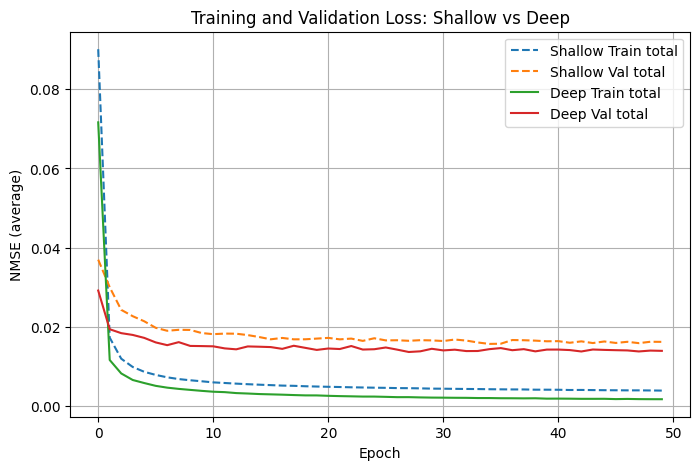

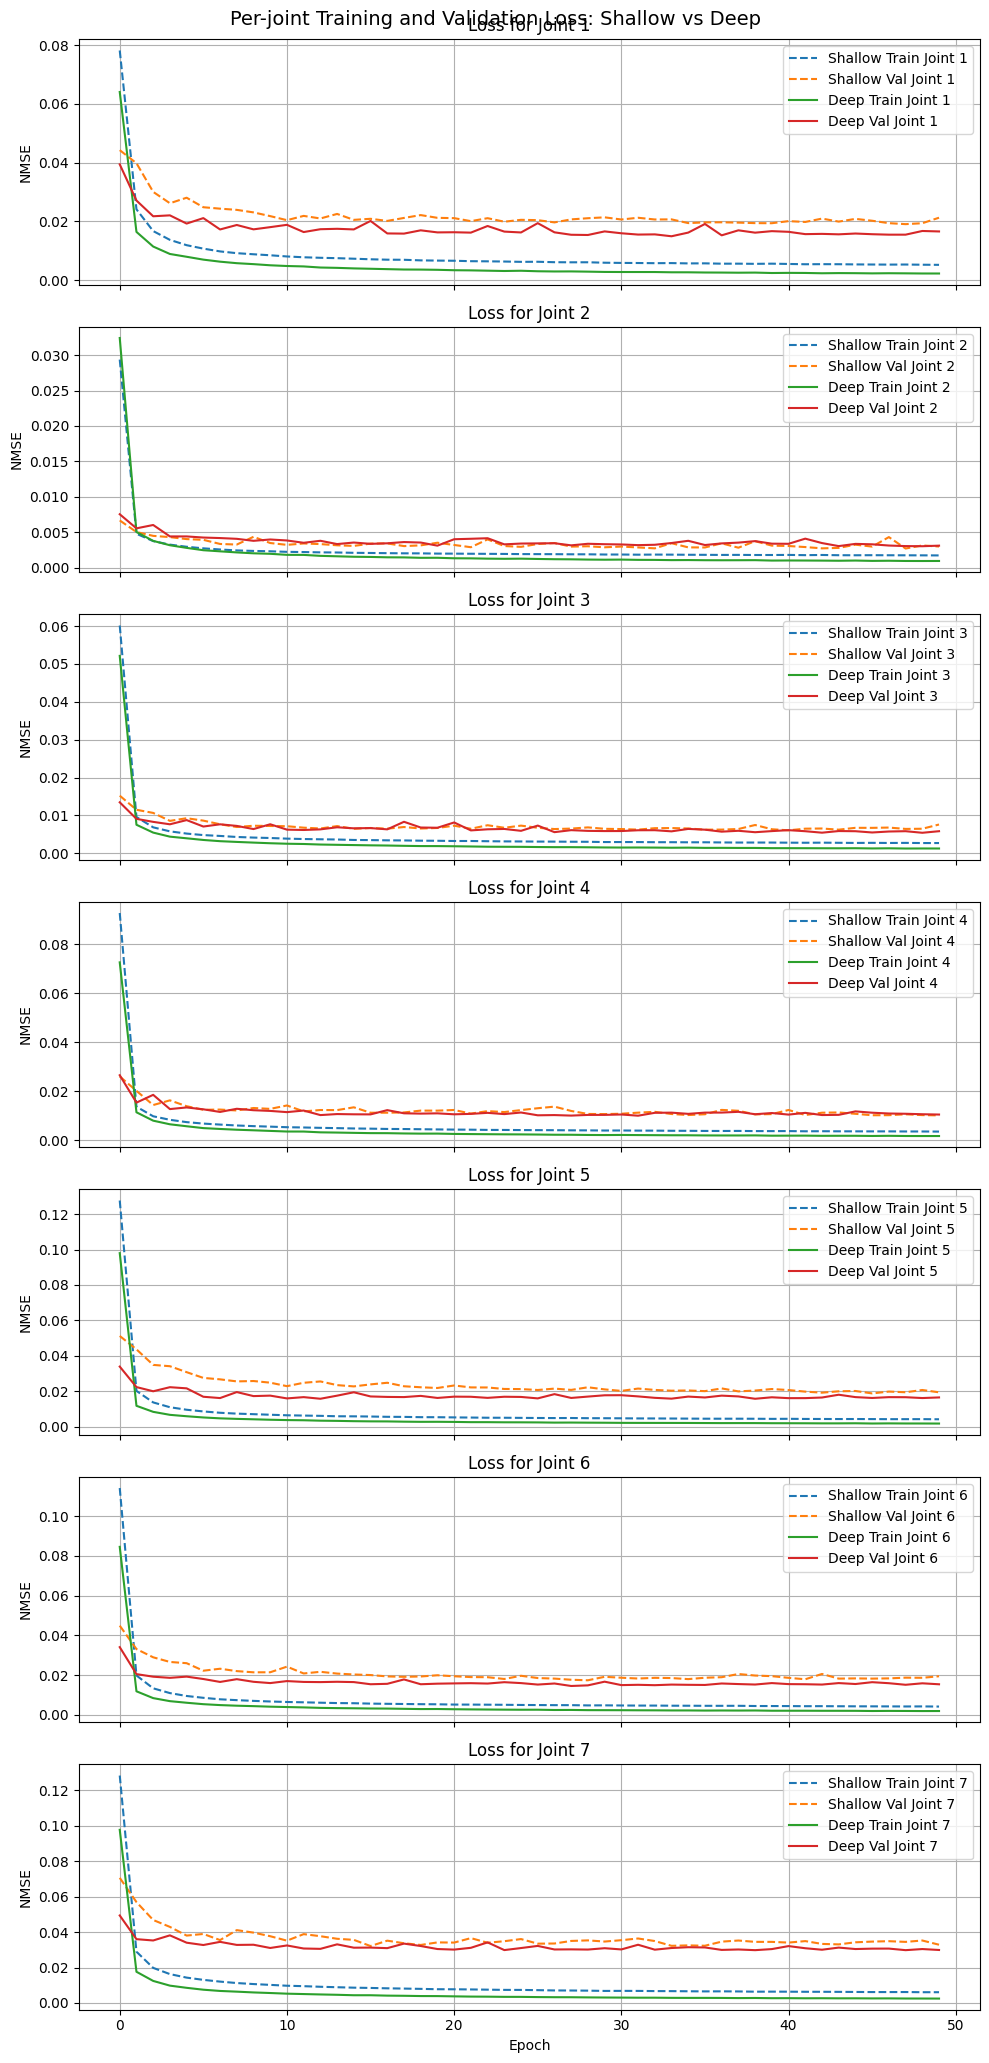

In [20]:
train_loss_log_shallow = np.array(train_loss_log_shallow)
val_loss_log_shallow   = np.array(val_loss_log_shallow)
train_loss_joints_log_shallow = np.array(train_loss_joints_log_shallow)
val_loss_joints_log_shallow   = np.array(val_loss_joints_log_shallow)

train_loss_log_deep = np.array(train_loss_log_deep)
val_loss_log_deep   = np.array(val_loss_log_deep)
train_loss_joints_log_deep = np.array(train_loss_joints_log_deep)
val_loss_joints_log_deep   = np.array(val_loss_joints_log_deep)

num_epochs_shallow = len(train_loss_log_shallow)
num_epochs_deep    = len(train_loss_log_deep)
n_joints = train_loss_joints_log_shallow.shape[1]

# --- Plotting  ---
plt.figure(figsize=(8, 5))
plt.plot(range(num_epochs_shallow), train_loss_log_shallow, label="Shallow Train total", linestyle="--")
plt.plot(range(num_epochs_shallow), val_loss_log_shallow, label="Shallow Val total", linestyle="--")
plt.plot(range(num_epochs_deep), train_loss_log_deep, label="Deep Train total")
plt.plot(range(num_epochs_deep), val_loss_log_deep, label="Deep Val total")
plt.xlabel("Epoch")
plt.ylabel("NMSE (average)")
plt.title("Training and Validation Loss: Shallow vs Deep")
plt.legend()
plt.grid(True)
plt.show()

# --- Plot per giunto ---
fig, axes = plt.subplots(n_joints, 1, figsize=(10, 3 * n_joints), sharex=True)

if n_joints == 1:
    axes = [axes]

for j in range(n_joints):
    axes[j].plot(range(num_epochs_shallow), train_loss_joints_log_shallow[:, j], label=f"Shallow Train Joint {j+1}", linestyle="--")
    axes[j].plot(range(num_epochs_shallow), val_loss_joints_log_shallow[:, j], label=f"Shallow Val Joint {j+1}", linestyle="--")
    axes[j].plot(range(num_epochs_deep), train_loss_joints_log_deep[:, j], label=f"Deep Train Joint {j+1}")
    axes[j].plot(range(num_epochs_deep), val_loss_joints_log_deep[:, j], label=f"Deep Val Joint {j+1}")
    axes[j].set_ylabel("NMSE")
    axes[j].legend()
    axes[j].grid(True)
    axes[j].set_title(f"Loss for Joint {j+1}")

axes[-1].set_xlabel("Epoch")

plt.suptitle("Per-joint Training and Validation Loss: Shallow vs Deep", fontsize=14)
plt.tight_layout()
plt.show()

## Comparative Performance Analysis on data out of distribution

=== SHALLOW NETWORK ===
AVERAGE TEST LOSS: 4.352114677429199
TEST LOSS JOINTS: [1.8409194e+00 1.4660802e+01 8.8185244e+00 4.6868968e+00 2.0335986e-01
 2.5339493e-01 9.2976866e-04]

=== DEEP NETWORK ===
AVERAGE TEST LOSS: 5.291602611541748
TEST LOSS JOINTS: [1.4204401e+00 2.0689371e+01 8.9692793e+00 5.5149555e+00 1.7895271e-01
 2.6740611e-01 7.9772080e-04]


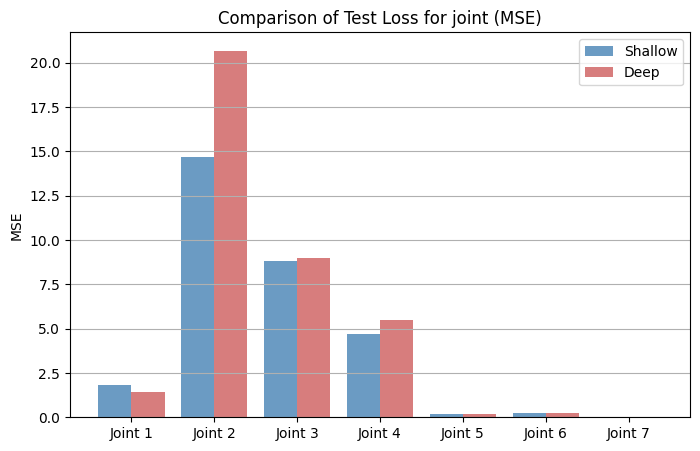

In [26]:
# SPIEGARE BENE CHE SI TRATTA DI MSE ERROR
def evaluate_network(net, test_dataloader, device, mean_y, std_y, test_data_normalized = False):
    """
    Funzione per valutare una rete su test set.
    Ritorna outputs, labels, test_loss medio e per giunto.
    """
    all_inputs = []
    all_outputs = []
    all_labels = []
    test_loss = []
    test_loss_joints = []

    net.eval()  # Evaluation mode (e.g. disable dropout)
    with torch.no_grad():  # Disable gradient tracking
        for sample_batched in test_dataloader:
            # Move data to device
            x_batch = sample_batched[0].to(device)
            label_batch = sample_batched[1].to(device)

            # Forward pass
            out = net(x_batch)

            out = out * std_y + mean_y

            # Loss
            loss = loss_fn(out, label_batch)
            loss_per_joints = mse_per_joint(out, label_batch)

            # Save val loss for this batch
            test_loss.append(loss.cpu().numpy())
            test_loss_joints.append(loss_per_joints.cpu().numpy())

            # Save outputs and labels
            all_inputs.append(x_batch)
            all_outputs.append(out)
            all_labels.append(label_batch)

    # Concatenate all the outputs and labels in a single tensor
    all_inputs  = torch.cat(all_inputs)
    all_outputs = torch.cat(all_outputs)
    all_labels  = torch.cat(all_labels)

    test_loss = np.mean(test_loss)
    test_loss_joints = np.mean(np.vstack(test_loss_joints), axis=0)

    return all_inputs, all_outputs, all_labels, test_loss, test_loss_joints

mean_y_tensor = torch.tensor(mean_y).float().to(device)
std_y_tensor = torch.tensor(std_y).float().to(device)

# Evaluating the shallow net
inputs_shallow, outputs_shallow, labels_shallow, test_loss_shallow, test_loss_joints_shallow = evaluate_network(
    net_shallow, test_dataloader, device, mean_y_tensor, std_y_tensor
)
print("=== SHALLOW NETWORK ===")
print(f"AVERAGE TEST LOSS: {test_loss_shallow}")
print(f"TEST LOSS JOINTS: {test_loss_joints_shallow}")

# --- Valutazione rete deep ---
inputs_deep, outputs_deep, labels_deep, test_loss_deep, test_loss_joints_deep = evaluate_network(net_deep, test_dataloader, device, mean_y_tensor, std_y_tensor)
print("\n=== DEEP NETWORK ===")
print(f"AVERAGE TEST LOSS: {test_loss_deep}")
print(f"TEST LOSS JOINTS: {test_loss_joints_deep}")


# --- Confronto grafico per giunto ---
n_joints = test_loss_joints_shallow.shape[0]
x = np.arange(n_joints)

plt.figure(figsize=(8,5))
plt.bar(x - 0.2, test_loss_joints_shallow, width=0.4, label="Shallow",  alpha=0.8, color='steelblue')
plt.bar(x + 0.2, test_loss_joints_deep, width=0.4, label="Deep",  alpha=0.8, color='indianred')
plt.xticks(x, [f"Joint {i+1}" for i in range(n_joints)])
plt.ylabel("MSE")
plt.title("Comparison of Test Loss for joint (MSE)")
plt.legend()
plt.grid(True, axis="y")
plt.show()



=== SHALLOW NETWORK ===
AVERAGE TEST LOSS: 2.894162654876709
TEST LOSS JOINTS: [9.1755259e-01 9.0756569e+00 5.1074886e+00 4.7768698e+00 8.2349747e-02
 2.9855949e-01 6.6262262e-04]


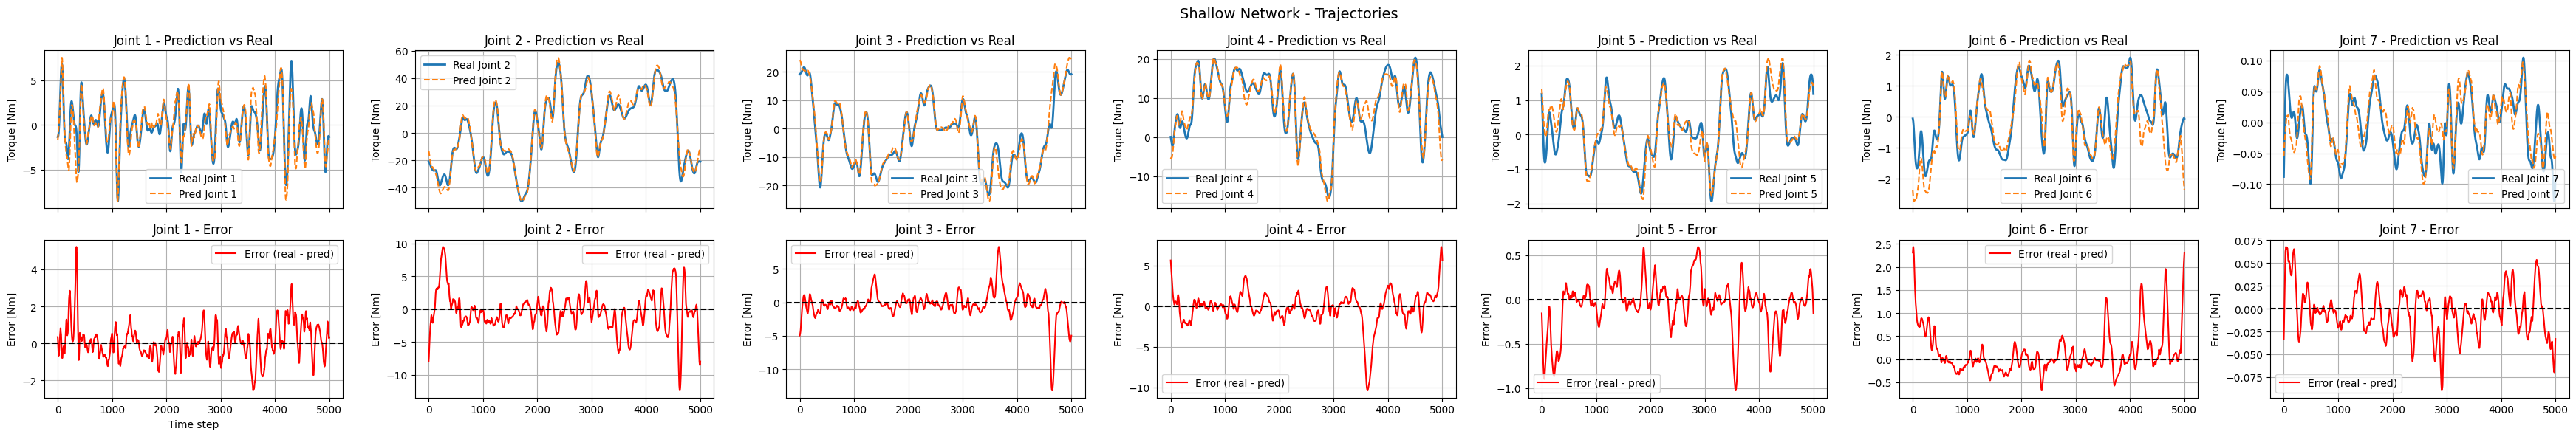


=== DEEP NETWORK ===
AVERAGE TEST LOSS: 3.105774164199829
TEST LOSS JOINTS: [1.0436246e+00 7.9844594e+00 5.9581738e+00 6.4025044e+00 8.4219217e-02
 2.6668260e-01 7.5472868e-04]


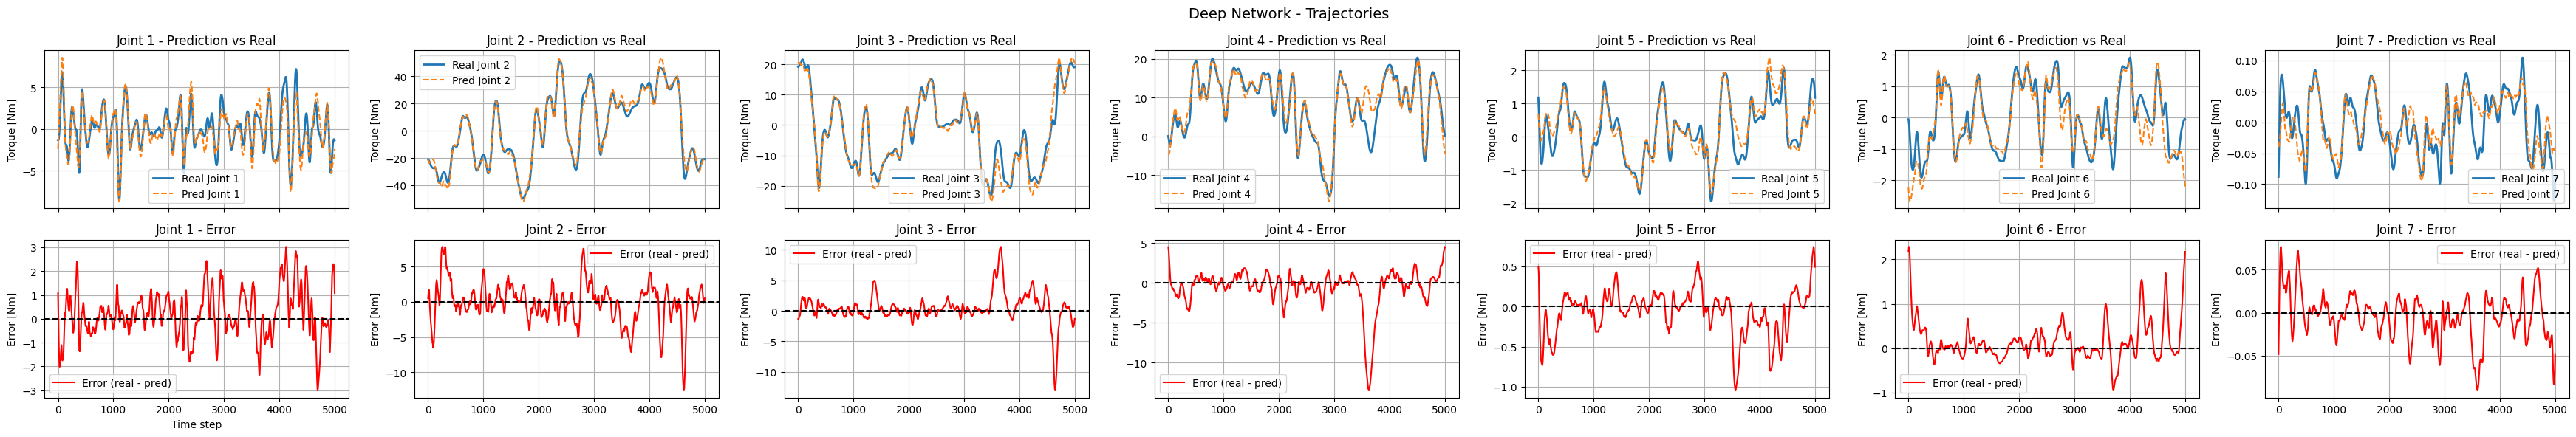

In [22]:
# Create OOD dataset for trajectory visualization (random file selection)
test_trajectory_dataset = PklDataset(f'/content/drive/MyDrive/NNDL_PROGETTO/data_out_of_distribution/{n_dof}dof/', random_choice=True, transform=composed_transform)
test_trajectory_dataloader = DataLoader(test_trajectory_dataset, batch_size=64, shuffle=False, num_workers=0)


def plot_joint_trajectories(outputs, labels, title="Predicted vs Real Torques and Errors"):
    """
    Plots the trajectories (predicted vs. ground truth) and the residuals (errors) for each joint.
    """
    # Convert tensors to numpy arrays for plotting
    outputs = outputs.cpu().numpy()
    labels = labels.cpu().numpy()

    n_samples, n_joints = outputs.shape
    time = np.arange(n_samples)  # x-axis representing time steps (samples)

    fig, axes = plt.subplots(2, n_joints, figsize=(5 * n_joints, 6), sharex=True)

    # Reshape axes for consistency if only one joint is present
    if n_joints == 1:
        axes = axes.reshape(2, 1)

    # --- 1) Predicted vs. Ground Truth (Real) ---
    for j in range(n_joints):
        axes[0, j].plot(time, labels[:, j], label=f"Real Joint {j+1}", linewidth=2)
        axes[0, j].plot(time, outputs[:, j], label=f"Pred Joint {j+1}", linestyle="--")
        axes[0, j].set_ylabel("Torque [Nm]")
        axes[0, j].legend()
        axes[0, j].grid(True)
        axes[0, j].set_title(f"Joint {j+1} - Prediction vs Real")

    # --- 2) Residuals (Error) ---
    errors = labels - outputs
    for j in range(n_joints):
        axes[1, j].plot(time, errors[:, j], color="red", label="Error (real - pred)")
        axes[1, j].axhline(0, color="black", linestyle="--")  # Zero-error reference line
        axes[1, j].set_ylabel("Error [Nm]")
        axes[1, j].legend()
        axes[1, j].grid(True)
        axes[1, j].set_title(f"Joint {j+1} - Error")

    axes[1, 0].set_xlabel("Time step")
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


# === EVALUATION EXAMPLE: SHALLOW VS DEEP ===

# Evaluate Shallow Network
inputs_shallow, outputs_shallow, labels_shallow, test_loss_shallow, test_loss_joints_shallow = evaluate_network(
    net_shallow, test_trajectory_dataloader, device, mean_y_tensor, std_y_tensor
)
print("=== SHALLOW NETWORK ===")
print(f"AVERAGE TEST LOSS: {test_loss_shallow}")
print(f"TEST LOSS JOINTS: {test_loss_joints_shallow}")
plot_joint_trajectories(outputs_shallow, labels_shallow, title="Shallow Network - Trajectories")

# Evaluate Deep Network
inputs_deep, outputs_deep, labels_deep, test_loss_deep, test_loss_joints_deep = evaluate_network(
    net_deep, test_trajectory_dataloader, device, mean_y_tensor, std_y_tensor
)
print("\n=== DEEP NETWORK ===")
print(f"AVERAGE TEST LOSS: {test_loss_deep}")
print(f"TEST LOSS JOINTS: {test_loss_joints_deep}")
plot_joint_trajectories(outputs_deep, labels_deep, title="Deep Network - Trajectories")